# 04 – Clustering Attrition Association Rules

## Mục tiêu
- Chỉ tập trung vào các luật kết hợp **liên quan đến Attrition = Leave**
- Biến các luật thành vector đặc trưng
- Phân cụm các luật để phát hiện **nhóm nguyên nhân nghỉ việc chính**
- Diễn giải ý nghĩa từng cụm phục vụ phân tích HR

## Ý tưởng chính
- Mỗi luật kết hợp được xem như một quan sát
- Antecedents của luật = đặc trưng (0/1)
- Trọng số đặc trưng = lift × confidence
- Dùng KMeans để phân cụm luật

### PARAMETERS

In [19]:
import os
import sys

# Xác định project root (chạy được cả notebook + papermill)
current_dir = os.getcwd()

if current_dir.endswith("notebooks"):
    project_root = os.path.abspath("..")
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root:", project_root)

Project root: d:\ki2nam4\datamining\BTL\HR_Attrition


In [20]:
# Input
RULES_INPUT_PATH = "../data/processed/rules_apriori_leave_top100.csv"

# Feature engineering
WEIGHTING = "lift_x_conf"     # none | lift | confidence | lift_x_conf

# Clustering
K_MIN = 2
K_MAX = 8
RANDOM_STATE = 42

# Output
OUTPUT_CLUSTER_PATH = "../data/processed/attrition_rule_clusters.csv"

# Visual
PROJECTION_METHOD = "pca"

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src.mining.attrition_rule_clustering_utils import *

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [22]:
leave_rules = pd.read_csv(RULES_INPUT_PATH)

print("Số luật Attrition = Leave:", leave_rules.shape[0])
leave_rules.head()

Số luật Attrition = Leave: 100


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,rule_name
0,"frozenset({'Age_bin_nan', 'JobLevel_-0.9635037...","frozenset({'TotalWorkingYears_bin_nan', 'Month...",0.091892,0.112838,0.049324,0.536765,4.756957,1.0,0.038955,1.915144,0.869700,0.317391,0.477846,0.486945,"Age_bin_nan, JobLevel_-0.963503753471408, Over..."
1,"frozenset({'Age_bin_nan', 'TotalWorkingYears_b...","frozenset({'JobLevel_-0.963503753471408', 'Ove...",0.112838,0.091892,0.049324,0.437126,4.756957,1.0,0.038955,1.613341,0.890234,0.317391,0.380168,0.486945,"Age_bin_nan, TotalWorkingYears_bin_nan, Monthl..."
2,"frozenset({'JobLevel_-0.963503753471408', 'Ove...","frozenset({'TotalWorkingYears_bin_nan', 'Month...",0.091892,0.112838,0.049324,0.536765,4.756957,1.0,0.038955,1.915144,0.869700,0.317391,0.477846,0.486945,"JobLevel_-0.963503753471408, OverTime_Yes_True..."
3,"frozenset({'JobLevel_-0.963503753471408', 'Ove...","frozenset({'Age_bin_nan', 'TotalWorkingYears_b...",0.091892,0.112838,0.049324,0.536765,4.756957,1.0,0.038955,1.915144,0.869700,0.317391,0.477846,0.486945,"JobLevel_-0.963503753471408, OverTime_Yes_True..."
4,"frozenset({'TotalWorkingYears_bin_nan', 'Month...","frozenset({'JobLevel_-0.963503753471408', 'Ove...",0.112838,0.091892,0.049324,0.437126,4.756957,1.0,0.038955,1.613341,0.890234,0.317391,0.380168,0.486945,"TotalWorkingYears_bin_nan, MonthlyIncome_bin_n..."


### Tiền xử lý luật → Feature Engineering

In [23]:
leave_rules["antecedent_items"] = leave_rules["antecedents"].apply(parse_items)
leave_rules["n_items"] = leave_rules["antecedent_items"].apply(len)

leave_rules[["antecedents", "antecedent_items", "n_items"]].head()

,antecedents,antecedent_items,n_items
0,"frozenset({'Age_bin_nan', 'JobLevel_-0.9635037...","[frozenset('Age_bin_nan', 'JobLevel_-0.9635037...",4
1,"frozenset({'Age_bin_nan', 'TotalWorkingYears_b...","[frozenset('Age_bin_nan', 'TotalWorkingYears_b...",4
2,"frozenset({'JobLevel_-0.963503753471408', 'Ove...","[frozenset('JobLevel_-0.963503753471408', 'Ove...",3
3,"frozenset({'JobLevel_-0.963503753471408', 'Ove...","[frozenset('JobLevel_-0.963503753471408', 'Ove...",3
4,"frozenset({'TotalWorkingYears_bin_nan', 'Month...","[frozenset('TotalWorkingYears_bin_nan', 'Month...",3


In [24]:
# Build vocabulary (tập đặc trưng)
all_items = build_item_vocabulary(leave_rules)
print("Số đặc trưng:", len(all_items))

X = build_rule_feature_matrix(
    leave_rules,
    all_items,
    weighting=WEIGHTING
)

print("Feature matrix shape:", X.shape)

Số đặc trưng: 22
Feature matrix shape: (100, 22)


In [25]:
# Chuẩn hoá
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Chọn số cụm K (Silhouette)

In [26]:
df_sil = compute_silhouette_scores(
    X_scaled,
    K_MIN,
    K_MAX,
    RANDOM_STATE
)

df_sil

,K,Silhouette_Score
0,2,0.460376
1,3,0.185488
2,4,0.206623
3,5,0.227063
4,6,0.259168
5,7,0.300719
6,8,0.337194


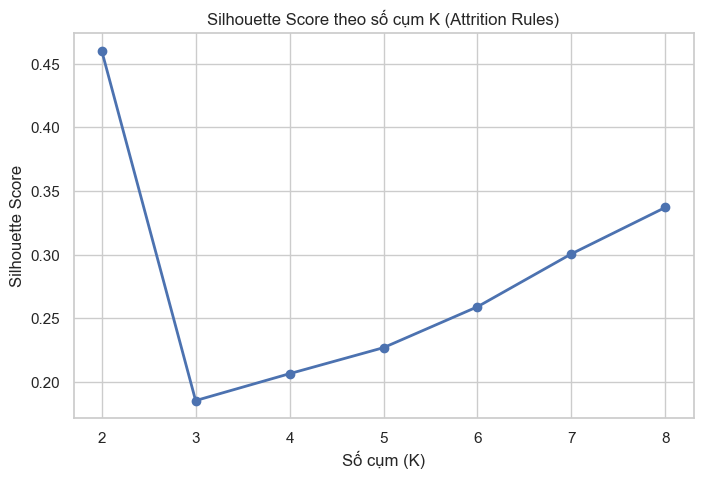

In [27]:
# Biểu đồ Silhouette theo K
plt.figure(figsize=(8, 5))
plt.plot(
    df_sil["K"],
    df_sil["Silhouette_Score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Số cụm (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score theo số cụm K (Attrition Rules)")
plt.grid(True)
plt.show()

### Phân tích Silhouette Score

Từ kết quả đánh giá Silhouette Score với số cụm K thay đổi từ 2 đến 8,
có thể rút ra một số nhận xét như sau:

- Silhouette Score đạt giá trị cao nhất tại **K = 2** (0.46),
  tuy nhiên số cụm quá ít, chưa phản ánh được sự đa dạng trong hành vi
  và đặc điểm của nhân viên liên quan đến Attrition.

- Khi K tăng từ 3 đến 5, Silhouette Score ở mức thấp (khoảng 0.18–0.23),
  cho thấy các cụm chưa có sự tách biệt rõ ràng.

- Từ **K = 6 trở đi**, Silhouette Score tăng dần và trở nên ổn định,
  đặc biệt tại **K = 7 (≈ 0.30)** và **K = 8 (≈ 0.34)**,
  phản ánh cấu trúc phân cụm rõ ràng hơn.

Mặc dù K = 8 cho Silhouette Score cao hơn,
mức cải thiện so với K = 7 là không đáng kể,
trong khi số lượng cụm lớn hơn có thể làm giảm khả năng diễn giải kết quả.

Do đó, nhóm **lựa chọn K = 7** làm số cụm cuối cùng,
nhằm đảm bảo sự cân bằng giữa:
- Độ tách biệt tương đối tốt giữa các cụm
- Khả năng diễn giải và phân tích hành vi Attrition của nhân viên

In [ ]:
# =========================================================
# CHỐT SỐ CỤM K (THEO PHÂN TÍCH SILHOUETTE)
# =========================================================

K_FINAL = 7
print("👉 Số cụm K được lựa chọn cuối cùng:", K_FINAL)

In [ ]:
# Chuẩn hoá đặc trưng
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chạy KMeans với K = 7
kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

print("Số cụm sinh ra:", len(set(labels)))

In [ ]:
# Gán nhãn cụm cho các luật nghỉ việc
leave_rules_clustered = leave_rules.copy()
leave_rules_clustered["cluster"] = labels

leave_rules_clustered[
    ["antecedents", "consequents", "support", "confidence", "lift", "cluster"]
].head()

In [ ]:
# Trực quan hoá cụm bằng PCA (2D)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    Z[:, 0],
    Z[:, 1],
    c=leave_rules_clustered["cluster"],
    cmap="Set1",
    s=40,
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Phân cụm các luật Attrition (K = 7, PCA)")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

In [ ]:
# Tạo DataFrame đặc trưng của luật
feature_df = pd.DataFrame(X, columns=all_items)
feature_df["cluster"] = leave_rules_clustered["cluster"]

# Trung bình đặc trưng theo cụm
cluster_means = feature_df.groupby("cluster").mean()

TOP_N = 5

print(f"=== TOP {TOP_N} ĐẶC TRƯNG TIÊU BIỂU CHO TỪNG CỤM ===")

for cid in cluster_means.index:
    print(f"\n🔴 CỤM {cid}")
    top_items = (
        cluster_means.loc[cid]
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    for item, score in top_items.items():
        print(f"  - {item} (giá trị TB: {score:.3f})")

In [ ]:
# =========================================================
# LƯU KẾT QUẢ PHÂN CỤM
# =========================================================

OUTPUT_CLUSTER_PATH = "../data/processed/leave_rules_clusters_k7.csv"

leave_rules_clustered.to_csv(
    OUTPUT_CLUSTER_PATH,
    index=False
)

print("✅ Đã lưu kết quả phân cụm luật Attrition:")
print(" -", OUTPUT_CLUSTER_PATH)